<a href="https://colab.research.google.com/github/Killeryoung/ML/blob/main/%D0%9B%D0%A02_%D0%93%D1%83%D1%80%D0%BA%D0%BE_%D0%A4%D0%86%D0%A2_3_10_%D0%97%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2. Гурко Данило ФІТ 3-10

---



# Завдання 1

**Був присутній на парі**

Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"

html = requests.get(
    url,
    headers={"User-Agent": "Mozilla/5.0"}
).text

tables = pd.read_html(html)

df = tables[2]

df.columns = df.columns.astype(str).str.replace(r'\[\d+\]', '', regex=True)
df = df.replace(r'\[[^\]]+\]', '', regex=True)

df.head()

/tmp/ipykernel_1877/3167214305.py:8: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


,Country/Territory,IMF (2026),World Bank (2025),United Nations (2024)
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China,20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Country/Territory      222 non-null    object
 1   IMF (2026)             222 non-null    object
 2   World Bank (2025)      222 non-null    object
 3   United Nations (2024)  222 non-null    object
dtypes: object(4)
memory usage: 7.1+ KB


2.	Визначити розмір датасета.

In [4]:
df.columns

Index(['Country/Territory', 'IMF (2026)', 'World Bank (2025)',
       'United Nations (2024)'],
      dtype='object')

 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [5]:
df.columns = (df.columns
              .str.replace(r'(?:\s"\[\d+\])+', '', regex=True)
              .str.replace('Country/Territory', 'Country', regex=False))
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China,20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


In [6]:
df = df.drop(df[df.iloc[:, 0] == "World"].index)
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
1,United States,32383920,30769700,29298000
2,China,20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
5,United Kingdom,4264794,4002588,3685881
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [7]:
df.isnull().sum()

,0
Country,0
IMF (2026),0
World Bank (2025),0
United Nations (2024),0


In [8]:
df['IMF (2026)'] = pd.to_numeric(df['IMF (2026)'], errors='coerce')
df['World Bank (2025)'] = pd.to_numeric(df['World Bank (2025)'], errors='coerce')
df['United Nations (2024)'] = pd.to_numeric(df['United Nations (2024)'], errors='coerce')

In [9]:
df.dtypes

,0
Country,object
IMF (2026),float64
World Bank (2025),float64
United Nations (2024),float64


In [10]:
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
1,United States,32383920.0,30769700.0,29298000.0
2,China,20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
5,United Kingdom,4264794.0,4002588.0,3685881.0
...,...,...,...,...
217,Palau,377.0,345.0,310.0
218,Marshall Islands,342.0,308.0,281.0
219,Nauru,196.0,176.0,187.0
220,Montserrat,NaN,NaN,81.0


In [11]:
df.isnull().sum()

,0
Country,0
IMF (2026),31
World Bank (2025),35
United Nations (2024),9


In [12]:
df = df.replace('—', np.nan)

num_cols = ['IMF (2026)', 'World Bank (2025)', 'United Nations (2024)']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].mean())

df.isnull().sum()


,0
Country,0
IMF (2026),0
World Bank (2025),0
United Nations (2024),0


In [28]:
df.isnull().sum()

,0
Country,0
IMF (2026),0
World Bank (2025),0
United Nations (2024),0
IMF_WB_Diff,0
Average_GDP,0
Std_Dev,0
IMF (2026) Share (%),0
World Bank (2025) Share (%),0
United Nations (2024) Share (%),0


5. Ще раз вивести датасет

In [14]:
df.tail(10)

,Country,IMF (2026),World Bank (2025),United Nations (2024)
212,Saint Martin,661460.289474,626049.693548,522491.207547
213,Federated States of Micronesia,521.000000,502.000000,471.000000
214,Anguilla,661460.289474,626049.693548,456.000000
215,Cook Islands,661460.289474,626049.693548,414.000000
216,Kiribati,401.000000,349.000000,343.000000
217,Palau,377.000000,345.000000,310.000000
218,Marshall Islands,342.000000,308.000000,281.000000
219,Nauru,196.000000,176.000000,187.000000
220,Montserrat,661460.289474,626049.693548,81.000000
221,Tuvalu,65.000000,57.000000,56.000000


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [15]:
df.duplicated().sum()

np.int64(0)

7.	Вивести описову статистику датасету describe()

In [16]:
df.describe()

,IMF (2026),World Bank (2025),United Nations (2024)
count,2.210000e+02,2.210000e+02,2.210000e+02
mean,6.614603e+05,6.260497e+05,5.224912e+05
std,2.666759e+06,2.520399e+06,2.410079e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,1.895900e+04,1.992800e+04,8.840000e+03
50%,1.020420e+05,9.977400e+04,4.276500e+04
75%,6.614603e+05,6.260497e+05,2.986970e+05
max,3.238392e+07,3.076970e+07,2.929800e+07


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [17]:
df['IMF_WB_Diff'] = abs(df['IMF (2026)'] - df['World Bank (2025)'])

max_diff = df['IMF_WB_Diff'].max()

country = df[df['IMF_WB_Diff'] == max_diff]['Country'].values[0]
print(f'{country} has the largest difference between IMF and WB: {max_diff}')

df.head(10)

United States has the largest difference between IMF and WB: 1614220.0


,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff
1,United States,32383920.0,30769700.0,29298000.0,1614220.0
2,China,20851593.0,19498039.0,18743802.0,1353554.0
3,Germany,5452858.0,5050923.0,4659929.0,401935.0
4,Japan,4379253.0,4435163.0,4026211.0,55910.0
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0
6,India,4153191.0,3956067.0,3952244.0,197124.0
7,France,3596094.0,3366316.0,3160443.0,229778.0
8,Italy,2738164.0,2551557.0,2380825.0,186607.0
9,Russia,2656452.0,2561310.0,2173386.0,95142.0
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [18]:
cor_IMF_WB = df['IMF (2026)'].corr(df['World Bank (2025)'])
cor_IMF_UN = df['IMF (2026)'].corr(df['United Nations (2024)'])
cor_WB_UN = df['World Bank (2025)'].corr(df['United Nations (2024)'])

print(f'Correlation between IMF and WB: {cor_IMF_WB}')
print(f'Correlation between IMF and UN: {cor_IMF_UN}')
print(f'Correlation between WB and UN: {cor_WB_UN}')

Correlation between IMF and WB: 0.9986385217562858
Correlation between IMF and UN: 0.9973427521857388
Correlation between WB and UN: 0.997011380809274


In [19]:
correlations = {
    'IMF (2026) - World Bank (2025)': cor_IMF_WB,
    'IMF (2026) - United Nations (2024)': cor_IMF_UN,
    'World Bank (2025) - United Nations (2024)': cor_WB_UN
}

best_pair = max(correlations, key=correlations.get)
print(f'Найвища кореляція: {best_pair} = {correlations[best_pair]:.4f}')


Найвища кореляція: IMF (2026) - World Bank (2025) = 0.9986


Обчислити середнє значення за стовпцями

In [20]:
mean_values = df[['IMF (2026)', 'World Bank (2025)', 'United Nations (2024)']].mean()
print('Середні значення за стовпцями:')
print(mean_values)


Середні значення за стовпцями:
IMF (2026)               661460.289474
World Bank (2025)        626049.693548
United Nations (2024)    522491.207547
dtype: float64


In [21]:
df[['IMF (2026)', 'World Bank (2025)', 'United Nations (2024)']].mean().to_frame('Mean')

,Mean
IMF (2026),661460.289474
World Bank (2025),626049.693548
United Nations (2024),522491.207547


In [22]:
df['Average_GDP'] = df[['IMF (2026)', 'World Bank (2025)', 'United Nations (2024)']].mean(axis=1)
df[['Country', 'Average_GDP']].head(10)


,Country,Average_GDP
1,United States,3.081721e+07
2,China,1.969781e+07
3,Germany,5.054570e+06
4,Japan,4.280209e+06
5,United Kingdom,3.984421e+06
6,India,4.020501e+06
7,France,3.374284e+06
8,Italy,2.556849e+06
9,Russia,2.463716e+06
10,Brazil,2.367218e+06


11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [23]:
gdp_cols = ['IMF (2026)', 'World Bank (2025)', 'United Nations (2024)']
df['Std_Dev'] = df[gdp_cols].std(axis=1)

max_std_row = df.loc[df['Std_Dev'].idxmax()]
print(f"Найвища варіативність у країни {max_std_row['Country']}: {max_std_row['Std_Dev']:.2f}")

df[['Country', 'Std_Dev']].sort_values('Std_Dev', ascending=False).head(10)


Найвища варіативність у країни United States: 1543508.41


,Country,Std_Dev
1,United States,1.543508e+06
2,China,1.068002e+06
3,Germany,3.964771e+05
197,Sint Maarten,3.808672e+05
146,Palestine,3.723153e+05
220,Montserrat,3.720469e+05
215,Cook Islands,3.718548e+05
214,Anguilla,3.718306e+05
201,Turks and Caicos Islands,3.710803e+05
199,British Virgin Islands,3.710382e+05


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [24]:
for col in gdp_cols:
    max_row = df.loc[df[col].idxmax()]
    min_row = df.loc[df[col].idxmin()]
    print(f'{col}:')
    print(f"  Найвище значення: {max_row['Country']} — {max_row[col]:.0f}")
    print(f"  Найнижче значення: {min_row['Country']} — {min_row[col]:.0f}")


IMF (2026):
  Найвище значення: United States — 32383920
  Найнижче значення: Tuvalu — 65
World Bank (2025):
  Найвище значення: United States — 30769700
  Найнижче значення: Tuvalu — 57
United Nations (2024):
  Найвище значення: United States — 29298000
  Найнижче значення: Tuvalu — 56


13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

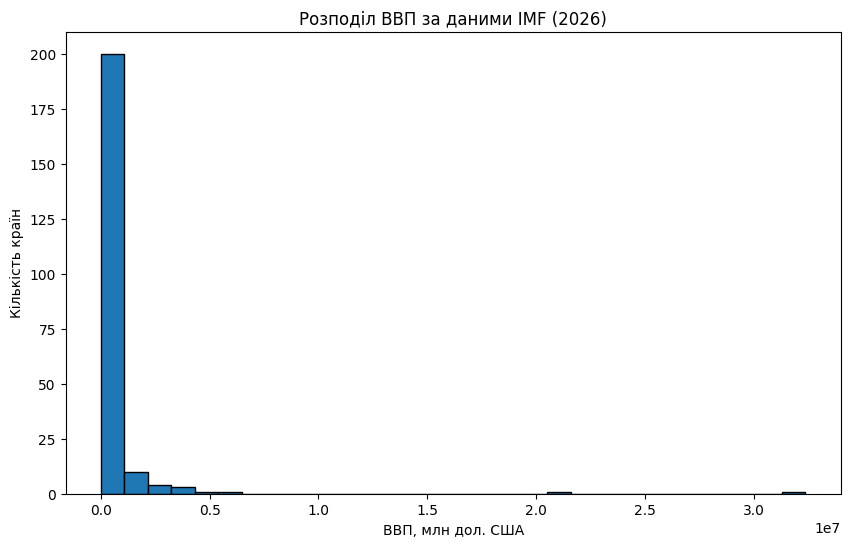

Розподіл правосторонньо асиметричний: більшість країн мають значно менший ВВП, а кілька великих економік виділяються.
Країни, що виділяються за правилом IQR:


,Country,IMF (2026)
1,United States,32383920.0
2,China,20851593.0
3,Germany,5452858.0
4,Japan,4379253.0
5,United Kingdom,4264794.0
6,India,4153191.0
7,France,3596094.0
8,Italy,2738164.0
9,Russia,2656452.0
10,Brazil,2635912.0


In [25]:
plt.figure(figsize=(10, 6))
plt.hist(df['IMF (2026)'], bins=30, edgecolor='black')
plt.title('Розподіл ВВП за даними IMF (2026)')
plt.xlabel('ВВП, млн дол. США')
plt.ylabel('Кількість країн')
plt.show()

q1 = df['IMF (2026)'].quantile(0.25)
q3 = df['IMF (2026)'].quantile(0.75)
iqr = q3 - q1
outliers = df[df['IMF (2026)'] > q3 + 1.5 * iqr][['Country', 'IMF (2026)']].sort_values('IMF (2026)', ascending=False)
print('Розподіл правосторонньо асиметричний: більшість країн мають значно менший ВВП, а кілька великих економік виділяються.')
print('Країни, що виділяються за правилом IQR:')
display(outliers)


14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [26]:
for col in gdp_cols:
    share_col = col + ' Share (%)'
    df[share_col] = df[col] / df[col].sum() * 100

share_cols = [col + ' Share (%)' for col in gdp_cols]
display(df[['Country'] + share_cols].head(10))

print('Зміна часток між IMF (2026) та United Nations (2024), в.п.:')
df['Share_change_2024_2026'] = df['IMF (2026) Share (%)'] - df['United Nations (2024) Share (%)']
display(df[['Country', 'Share_change_2024_2026']].sort_values('Share_change_2024_2026', ascending=False).head(10))
print('Позитивне значення означає збільшення частки, від’ємне — зменшення. Порівняння є орієнтовним, оскільки показники походять від різних організацій.')


,Country,IMF (2026) Share (%),World Bank (2025) Share (%),United Nations (2024) Share (%)
1,United States,22.153042,22.239355,25.372702
2,China,14.264061,14.092559,16.232538
3,Germany,3.730166,3.650646,4.035599
4,Japan,2.995739,3.205594,3.486786
5,United Kingdom,2.917441,2.892943,3.192053
6,India,2.841096,2.859319,3.422729
7,France,2.459999,2.433065,2.737012
8,Italy,1.873111,1.844184,2.061846
9,Russia,1.817213,1.851233,1.882199
10,Brazil,1.803162,1.647853,1.892969


Зміна часток між IMF (2026) та United Nations (2024), в.п.:


,Country,Share_change_2024_2026
220,Montserrat,0.452419
215,Cook Islands,0.452130
214,Anguilla,0.452094
197,Sint Maarten,0.451042
201,Turks and Caicos Islands,0.450967
199,British Virgin Islands,0.450904
196,Eritrea,0.450829
191,Zanzibar,0.450298
184,Greenland,0.449487
182,Curaçao,0.449405


Позитивне значення означає збільшення частки, від’ємне — зменшення. Порівняння є орієнтовним, оскільки показники походять від різних організацій.


15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

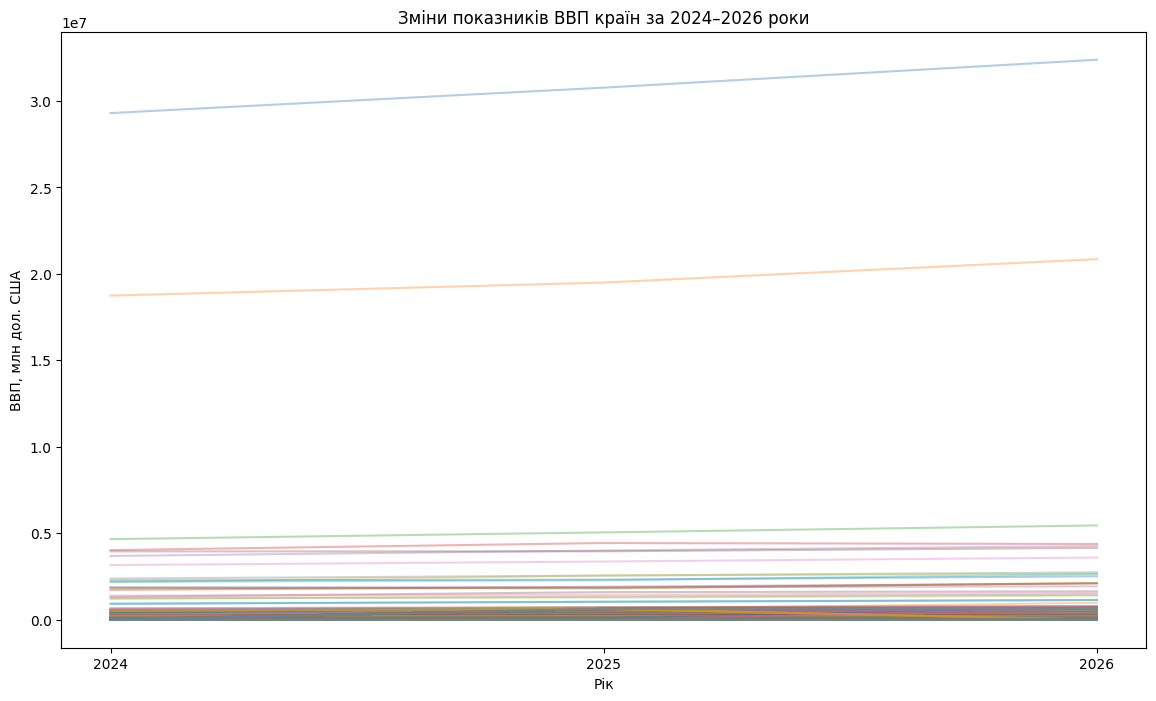

Країни зі стабільним зростанням:
United States, China, Germany, United Kingdom, India, France, Italy, Russia, Brazil, Canada, Spain, Turkey, Indonesia, Netherlands, Saudi Arabia, Switzerland, Poland, Taiwan, Ireland, Belgium, Sweden, Israel, Argentina, Singapore, Austria, Norway, Thailand, Colombia, Vietnam, Malaysia, Philippines, Bangladesh, Denmark, Romania, South Africa, Hong Kong, Czech Republic, Egypt, Chile, Pakistan, Peru, Portugal, Nigeria, Kazakhstan, Finland, Algeria, Greece, New Zealand, Hungary, Cuba, Ukraine, Morocco, Uzbekistan, Slovakia, Angola, Bulgaria, Kenya, Ecuador, Dominican Republic, Guatemala, DR Congo, Ghana, Oman, Croatia, Ivory Coast, Serbia, Luxembourg, Costa Rica, Sri Lanka, Lithuania, Belarus, Uruguay, Panama, Tanzania, Slovenia, Myanmar, Bolivia, Azerbaijan, Uganda, Cameroon, Jordan, Tunisia, Paraguay, Zimbabwe, Macau, Latvia, Cambodia, Estonia, Nepal, Cyprus, Iceland, Georgia, Honduras, Zambia, Senegal, El Salvador, Haiti, Bosnia and Herzegovina, Lebanon,

In [27]:
plot_df = df.set_index('Country')[['United Nations (2024)', 'World Bank (2025)', 'IMF (2026)']]

plt.figure(figsize=(14, 8))
for country, row in plot_df.iterrows():
    plt.plot([2024, 2025, 2026], row.values, alpha=0.35)
plt.title('Зміни показників ВВП країн за 2024–2026 роки')
plt.xlabel('Рік')
plt.ylabel('ВВП, млн дол. США')
plt.xticks([2024, 2025, 2026])
plt.show()

values = df[['United Nations (2024)', 'World Bank (2025)', 'IMF (2026)']]
growing = df[(values.iloc[:, 0] < values.iloc[:, 1]) & (values.iloc[:, 1] < values.iloc[:, 2])]['Country'].tolist()
declining = df[(values.iloc[:, 0] > values.iloc[:, 1]) & (values.iloc[:, 1] > values.iloc[:, 2])]['Country'].tolist()

print('Країни зі стабільним зростанням:')
print(', '.join(growing) if growing else 'Немає')
print('\nКраїни зі стабільним спадом:')
print(', '.join(declining) if declining else 'Немає')
print('\nПримітка: це порівняння оцінок різних організацій за різні роки, тому воно не є чистим часовим рядом одного джерела.')


### Висновок

У лабораторній роботі було завантажено та опрацьовано дані про номінальний ВВП країн із Wikipedia. Було очищено назви та значення від службових посилань, оброблено пропущені значення, перевірено дублікати та розраховано описову статистику. Також визначено різницю і кореляцію між показниками IMF, World Bank та United Nations, обчислено середні значення і стандартні відхилення, знайдено країни з найбільшими та найменшими показниками, розраховано частки країн у загальному ВВП і виконано візуалізацію розподілу та змін показників.
